In [46]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import string
import seaborn as sns
import plotly.express as px

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from textblob import TextBlob

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Download resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [47]:
url = ('https://raw.githubusercontent.com/cherrysober/tugas_Datmin/main/reviews_data.csv')
df = pd.read_csv(url)

df.head()

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


Load the dataset into a DataFrame using the URL link available on GitHub

In [48]:
df.drop(columns=['Image_Links'], inplace=True)

Deleting less relevant columns; the example above shows the deletion of the ‘Image_Links’ column

# Cleaning Text

In [49]:
df = df.drop(df[df['Review'] == 'review text'].index)
df = df.drop(df[df['Review'] == 'No Review Text'].index)

Delete the “review text” and “No Review Text” data rows in the Review column

In [50]:
def cleaning(text):
  text = re.sub(r'@[A-Za-z0-9_]+', '', text)
  text = re.sub(r'#\w+', '', text)
  text = re.sub(r'RT[\s]+', '', text)
  text = re.sub(r'https?://\S+', '', text)

  text = re.sub(r'[^A-Za-z0-9 ]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()

  return text

df['Review'] = df['Review'].apply(cleaning)

Cleaning text of various unwanted elements, particularly in the context of text data such as reviews found in the ‘Review’ column of the DataFrame df.

## Lowering Text

In [51]:
df['Review'] = df['Review'].apply(lambda x: x.lower())

Convert all text in the ‘Review’ column of the DataFrame df to lowercase

## Removing Stopwords

In [52]:
def remove_stopwords(text):
    stopwords_list = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word.lower() not in stopwords_list]
    return ' '.join(words)

df['Review'] = df['Review'].apply(remove_stopwords)

Remove stopwords from the text in the ‘Review’ column of the DataFrame df.

## Stemming

In [53]:
stemmer = PorterStemmer()

def stemming(text):
    words = word_tokenize(text)

    stemmed_words = [stemmer.stem(word) for word in words]

    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

df['Stemmed_Review'] = df['Review'].apply(stemming)

Perform stemming on the text in the ‘Review’ column of the DataFrame df and store the results in a new column named ‘Stemmed_Review’. Stemming here is the process of converting words to their root form, so that variations of the same word can be identified as the same word.

## Tokenizing

In [54]:
df['Tokenized_Review'] = df['Stemmed_Review'].apply(lambda x: word_tokenize(x))

Create a new column named ‘Tokenized_Review’ in the DataFrame df that contains a list of tokens (words) generated from the tokenization of the text in the ‘Stemmed_Review’ column.

In [55]:
df

,name,location,Date,Rating,Review,Stemmed_Review,Tokenized_Review
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,amber ladonna starbucks southwest parkway alwa...,amber ladonna starbuck southwest parkway alway...,"[amber, ladonna, starbuck, southwest, parkway,..."
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,starbucks fire station 436 altamonte springs f...,starbuck fire station 436 altamont spring fl m...,"[starbuck, fire, station, 436, altamont, sprin..."
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,wanted go way recognize starbucks employee bil...,want go way recogn starbuck employe billi fran...,"[want, go, way, recogn, starbuck, employe, bil..."
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,friend starbucks card didnt work thankful work...,friend starbuck card didnt work thank worker p...,"[friend, starbuck, card, didnt, work, thank, w..."
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,im kick drinking 5 cups warm water work instac...,im kick drink 5 cup warm water work instacart ...,"[im, kick, drink, 5, cup, warm, water, work, i..."
...,...,...,...,...,...,...,...
841,Mary,"Hillsboro, OR","Reviewed Dec. 16, 2007",NaN,using debit card much long starbucks company p...,use debit card much long starbuck compani put ...,"[use, debit, card, much, long, starbuck, compa..."
842,Angie,"Innsbruck, OR","Reviewed Sept. 17, 2007",NaN,bought starbucks thermos mug month half ago va...,bought starbuck thermo mug month half ago vaca...,"[bought, starbuck, thermo, mug, month, half, a..."
844,Sabine,"Redondo Beach, CA","Reviewed Dec. 19, 2006",NaN,im regular customer ordered latte 1250pm tuesd...,im regular custom order latt 1250pm tuesday 12...,"[im, regular, custom, order, latt, 1250pm, tue..."
845,Becky,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,ordered two venti frappacinos without whipped ...,order two venti frappacino without whip cream ...,"[order, two, venti, frappacino, without, whip,..."


In [56]:
def analyze_sentiment(review):
    blob = TextBlob(review)
    sentiment = blob.sentiment.polarity
    return sentiment

sentiments = []
for review in df['Review']:
    sentiment = analyze_sentiment(review)
    sentiments.append(sentiment)

df['Sentiment'] = sentiments

threshold = 0

def label_sentiment(polarity):
    if polarity > threshold:
        return 'Positive'
    else:
        return 'Negative'

df['Sentiment_Label'] = df['Sentiment'].apply(label_sentiment)

Analyze the sentiment of the text in the ‘Review’ column of the DataFrame df, add a numerical sentiment score to the ‘Sentiment’ column, and then add a sentiment label (‘Positive’ or ‘Negative’) based on that score to the ‘Sentiment_Label’ column

In [57]:
documents = []

for i in df['Stemmed_Review']:
    documents.append(i)

vectorizer = TfidfVectorizer()

features = vectorizer.fit_transform(documents)

Convert the text in the ‘Stemmed_Review’ column of the DataFrame df into a numerical feature representation using TF-IDF (Term Frequency-Inverse Document Frequency) with the help of the TfidfVectorizer from the scikit-learn library.

In [58]:
df

,name,location,Date,Rating,Review,Stemmed_Review,Tokenized_Review,Sentiment,Sentiment_Label
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,amber ladonna starbucks southwest parkway alwa...,amber ladonna starbuck southwest parkway alway...,"[amber, ladonna, starbuck, southwest, parkway,...",0.314286,Positive
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,starbucks fire station 436 altamonte springs f...,starbuck fire station 436 altamont spring fl m...,"[starbuck, fire, station, 436, altamont, sprin...",0.393939,Positive
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,wanted go way recognize starbucks employee bil...,want go way recogn starbuck employe billi fran...,"[want, go, way, recogn, starbuck, employe, bil...",-0.140000,Negative
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,friend starbucks card didnt work thankful work...,friend starbuck card didnt work thank worker p...,"[friend, starbuck, card, didnt, work, thank, w...",0.333333,Positive
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,im kick drinking 5 cups warm water work instac...,im kick drink 5 cup warm water work instacart ...,"[im, kick, drink, 5, cup, warm, water, work, i...",0.396561,Positive
...,...,...,...,...,...,...,...,...,...
841,Mary,"Hillsboro, OR","Reviewed Dec. 16, 2007",NaN,using debit card much long starbucks company p...,use debit card much long starbuck compani put ...,"[use, debit, card, much, long, starbuck, compa...",0.025000,Positive
842,Angie,"Innsbruck, OR","Reviewed Sept. 17, 2007",NaN,bought starbucks thermos mug month half ago va...,bought starbuck thermo mug month half ago vaca...,"[bought, starbuck, thermo, mug, month, half, a...",-0.091667,Negative
844,Sabine,"Redondo Beach, CA","Reviewed Dec. 19, 2006",NaN,im regular customer ordered latte 1250pm tuesd...,im regular custom order latt 1250pm tuesday 12...,"[im, regular, custom, order, latt, 1250pm, tue...",-0.009184,Negative
845,Becky,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,ordered two venti frappacinos without whipped ...,order two venti frappacino without whip cream ...,"[order, two, venti, frappacino, without, whip,...",0.300000,Positive


In [59]:
sentiment_mapping = {'Positive': 1, 'Negative': 0}
df['Sentiment_Numeric'] = df['Sentiment_Label'].map(sentiment_mapping)

Convert the sentiment labels in the ‘Sentiment_Label’ column to numerical values in a new column, ‘Sentiment_Numeric,’ in the DataFrame df. The goal is to facilitate analysis and the application of machine learning algorithms.

## **Basic Information with Heatmap**

In [60]:
df.corr(numeric_only = True)

,Rating,Sentiment,Sentiment_Numeric
Rating,1.000000,0.539952,0.381014
Sentiment,0.539952,1.000000,0.738377
Sentiment_Numeric,0.381014,0.738377,1.000000


In [61]:
px.imshow(df.corr(numeric_only = True))

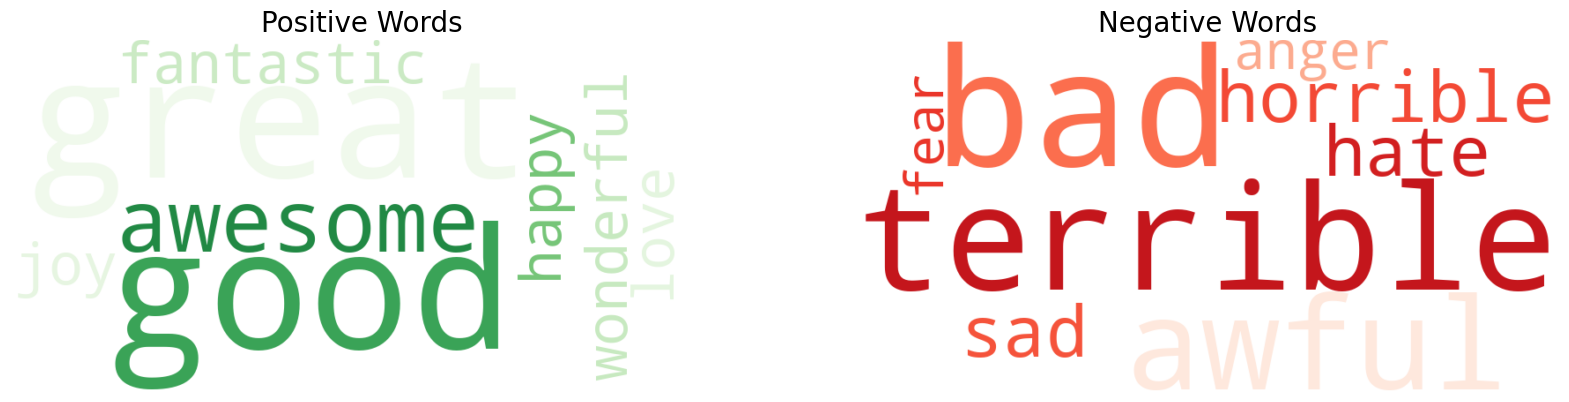

In [62]:
positive_words = "good great awesome fantastic wonderful happy joy love"
negative_words = "bad terrible awful horrible sad hate anger fear"

# Create word cloud for positive words
positive_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_words)

# Create word cloud for negative words
negative_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_words)

# Display word clouds
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# Positive word cloud
axs[0].imshow(positive_wordcloud, interpolation='bilinear')
axs[0].set_title('Positive Words', fontsize=20)
axs[0].axis('off')

# Negative word cloud
axs[1].imshow(negative_wordcloud, interpolation='bilinear')
axs[1].set_title('Negative Words', fontsize=20)
axs[1].axis('off')

plt.show()


Create and display a word cloud for two sets of words: positive words and negative words.

## **Exploratory Data Analysis**

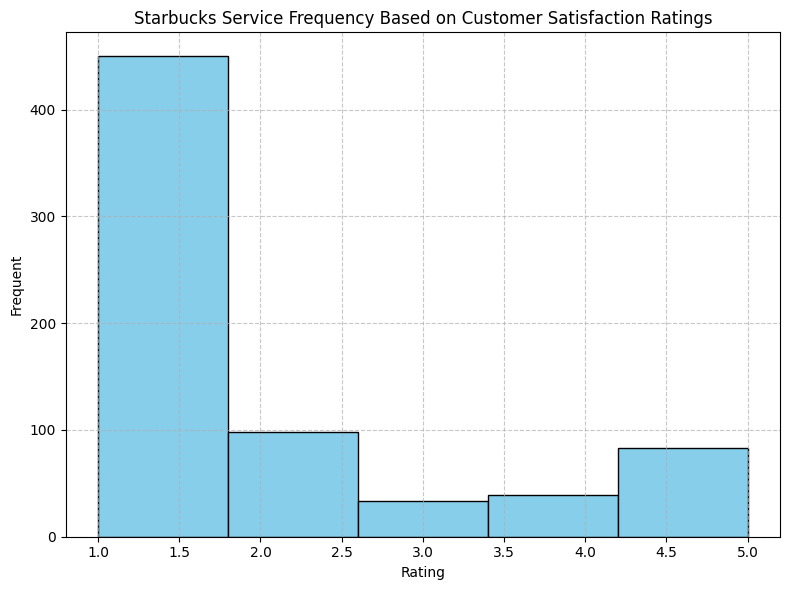

In [63]:
Rating_count = df['Rating'].value_counts()
max_value = Rating_count.max()

plt.figure(figsize=(8, 6))
sorted_data = df['Rating'].sort_values().reset_index(drop=True)
plt.hist(sorted_data, bins=5, color='skyblue', edgecolor='black')

plt.title('Starbucks Service Frequency Based on Customer Satisfaction Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequent')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The rating distribution is concentrated at lower rating levels, particularly ratings of 1.0 and 1.5, indicating that a substantial proportion of customers gave low ratings. However, sentiment analysis shows a slightly higher proportion of positive sentiment (53.1%) than negative sentiment (46.9%). This difference suggests that customer ratings and textual sentiment do not always produce consistent results, highlighting the importance of analyzing both numerical ratings and customer reviews.

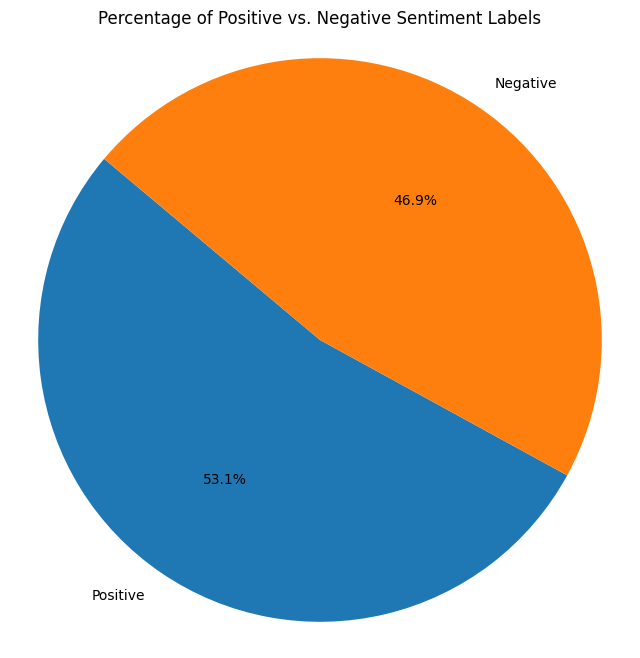

In [64]:
sentiment_counts = df['Sentiment_Label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Percentage of Positive vs. Negative Sentiment Labels')
plt.show()

The results are as follows:

- Positive sentiment accounts for 53.1% of the data.
- Negative sentiment accounts for 46.9% of the data.

# Modelling

## **Regresi Logistik**

In [65]:
X = features
y = df['Sentiment_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(y_pred)

0.7116564417177914
[1 1 0 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 1 0 1 0 0 1 1 1 1 0 0 0 1 1 0 1
 1 1 1 0 0 0 0 0 1 1 1 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 1 0 1 1 1 0 0 0 1 1 0
 1 0 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 0 1 0 0 0 1 1 1 0
 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 1 0 0 0 1 0 1 1
 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0]


Train and test a classification model using logistic regression to predict the sentiment of reviews.

# Evaluation

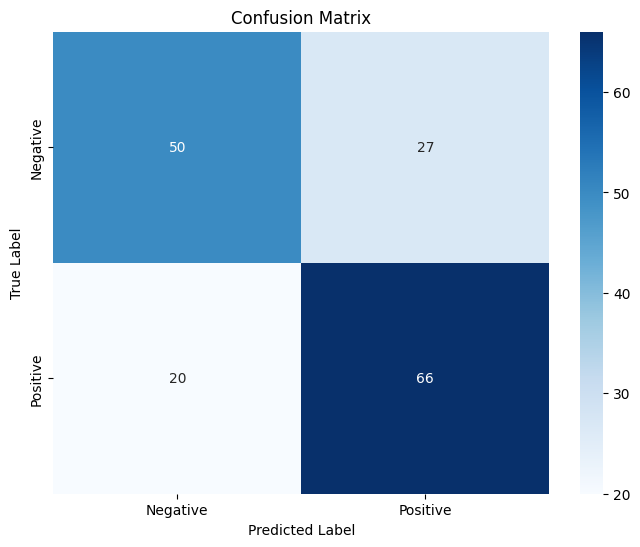

In [66]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Explanation of the Confusion Matrix:

1) True Negatives (TN): A value of 50 indicates the number of instances correctly predicted as negative.

2) False Positives (FP): A value of 27 indicates the number of instances incorrectly predicted as positive (actually negative).

3) False Negatives (FN): A value of 20 indicates the number of instances incorrectly predicted as negative (actually positive).

4) True Positives (TP): A value of 66 indicates the number of instances correctly predicted as positive.

In [67]:
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.65      0.68        77
           1       0.71      0.77      0.74        86

    accuracy                           0.71       163
   macro avg       0.71      0.71      0.71       163
weighted avg       0.71      0.71      0.71       163



Generates output that shows the performance of the classification model. This output includes several key metrics for each class, such as precision, recall, F1-score, and support.

The results are as follows:

- This model demonstrates balanced performance between negative and positive predictions, with an overall accuracy of 71%. The positive class (1) has a higher recall than the negative class (0), which means the model is better at identifying positive cases (1).
- Precision and recall are nearly balanced, but recall for the negative class (0) is slightly lower than for the positive class (1), indicating that the model is slightly better at recognizing positive-class samples than negative-class samples.

In [68]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.71


The results are as follows:

An accuracy score of 0.71 (71%) indicates that the model performs reasonably well, but there is still room for improvement.

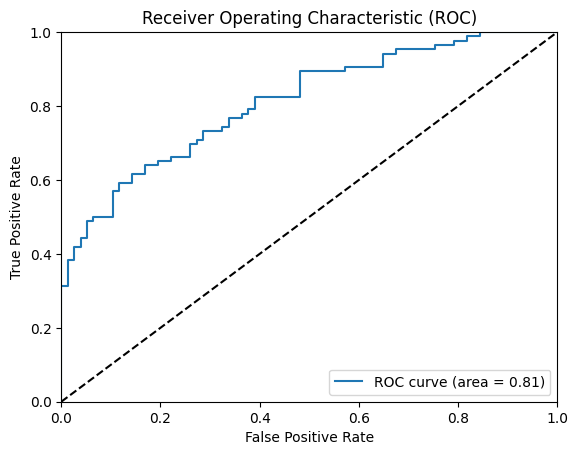

AUC Score: 0.81


In [69]:
# Prediction Probability
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_prob))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f'AUC Score: {auc_score:.2f}')

Results:

- Model Performance: With an AUC of 0.81, the model is able to identify positive and negative cases effectively. There is a good balance between sensitivity (the ability to detect true positives) and specificity (the ability to avoid false positives).

- Implications: This model can be used for prediction with the confidence that, approximately 81% of the time, it will yield better results than a random guess.